# Welcome to Colab!

In [14]:
# Step 1: Find medians
N_median = df['N'].median()
P_median = df['P'].median()
K_median = df['K'].median()

print("N median:", N_median)
print("P median:", P_median)
print("K median:", K_median)

# Step 2: Code as -1 or +1
df['N_coded'] = df['N'].apply(lambda x: 1 if x > N_median else -1)
df['P_coded'] = df['P'].apply(lambda x: 1 if x > P_median else -1)
df['K_coded'] = df['K'].apply(lambda x: 1 if x > K_median else -1)

# Step 3: Get mean PH for each combination
factorial_table = df.groupby(
    ['N_coded', 'P_coded', 'K_coded']
)['ph'].mean().reset_index()

factorial_table.columns = ['N', 'P', 'K', 'PH']
print(factorial_table)

# Step 4: Save CSV
factorial_table.to_csv('factorial_doe_table.csv', index=False)
print("✅ Saved!")

N median: 37.0
P median: 51.0
K median: 32.0
   N  P  K        PH
0 -1 -1 -1  6.470452
1 -1 -1  1  6.277527
2 -1  1 -1  6.384169
3 -1  1  1  6.263343
4  1 -1 -1  6.631522
5  1 -1  1  6.515992
6  1  1 -1  6.719081
7  1  1  1  6.526315
✅ Saved!


In [19]:
# Download factorial_doe_table.csv to your computer
from google.colab import files
files.download('factorial_doe_table.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Install required library
!pip install pyDOE2 statsmodels scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE2: filename=pyDOE2-1.3.0-py3-none-any.whl size=25523 sha256=a079aed7546e863d5112ca6cbc65dbd048a1345316504a9999403a45d7484f15
  Stored in directory: /root/.cache/pip/wheels/eb/43/4c/23f07750b9eefa81ef8d1a37f6a3ce1e6329b63312aa71150c
Successfully built pyDOE2
✅ All libraries loaded!


In [21]:
# Load dataset
df = pd.read_csv('/content/Crop_recommendation.csv')

# Find medians
N_med = df['N'].median()
P_med = df['P'].median()
K_med = df['K'].median()

print(f"N median: {N_med}")
print(f"P median: {P_med}")
print(f"K median: {K_med}")

# Code as -1 or +1
df['N_coded'] = df['N'].apply(lambda x: 1 if x > N_med else -1)
df['P_coded'] = df['P'].apply(lambda x: 1 if x > P_med else -1)
df['K_coded'] = df['K'].apply(lambda x: 1 if x > K_med else -1)

# Create 8-row factorial table
factorial_table = df.groupby(
    ['N_coded','P_coded','K_coded']
)['ph'].mean().reset_index()
factorial_table.columns = ['N','P','K','PH']

print("\n✅ Factorial Design Table (2³):")
print(factorial_table)

N median: 37.0
P median: 51.0
K median: 32.0

✅ Factorial Design Table (2³):
   N  P  K        PH
0 -1 -1 -1  6.470452
1 -1 -1  1  6.277527
2 -1  1 -1  6.384169
3 -1  1  1  6.263343
4  1 -1 -1  6.631522
5  1 -1  1  6.515992
6  1  1 -1  6.719081
7  1  1  1  6.526315


In [23]:
# Fit model WITHOUT 3-way interaction
# (not enough data points for full model)
model = ols('PH ~ N + P + K + N:P + N:K + P:K',
            data=factorial_table).fit()

print("=" * 50)
print("       MODEL SUMMARY")
print("=" * 50)
print(model.summary())

       MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                     PH   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     10.62
Date:                Sat, 23 May 2026   Prob (F-statistic):              0.231
Time:                        06:39:00   Log-Likelihood:                 20.497
No. Observations:                   8   AIC:                            -26.99
Df Residuals:                       1   BIC:                            -26.44
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.4736      0.01

In [24]:

anova_table = anova_lm(model, typ=1)

print("=" * 50)
print("         ANOVA TABLE")
print("=" * 50)
print(anova_table.round(4))

print("\n")
print("=" * 50)
print("    SIGNIFICANCE SUMMARY (p < 0.05)")
print("=" * 50)
for effect, row in anova_table.iterrows():
    if effect == 'Residual':
        continue
    p = row['PR(>F)']
    if p < 0.05:
        print(f"✅ {effect:10s} → SIGNIFICANT   (p = {p:.4f})")
    else:
        print(f"❌ {effect:10s} → NOT significant (p = {p:.4f})")

         ANOVA TABLE
           df  sum_sq  mean_sq        F  PR(>F)
N         1.0  0.1244   0.1244  44.6103  0.0946
P         1.0  0.0000   0.0000   0.0003  0.9890
K         1.0  0.0484   0.0484  17.3511  0.1500
N:P       1.0  0.0049   0.0049   1.7642  0.4108
N:K       1.0  0.0000   0.0000   0.0013  0.9768
P:K       1.0  0.0000   0.0000   0.0012  0.9781
Residual  1.0  0.0028   0.0028      NaN     NaN


    SIGNIFICANCE SUMMARY (p < 0.05)
❌ N          → NOT significant (p = 0.0946)
❌ P          → NOT significant (p = 0.9890)
❌ K          → NOT significant (p = 0.1500)
❌ N:P        → NOT significant (p = 0.4108)
❌ N:K        → NOT significant (p = 0.9768)
❌ P:K        → NOT significant (p = 0.9781)


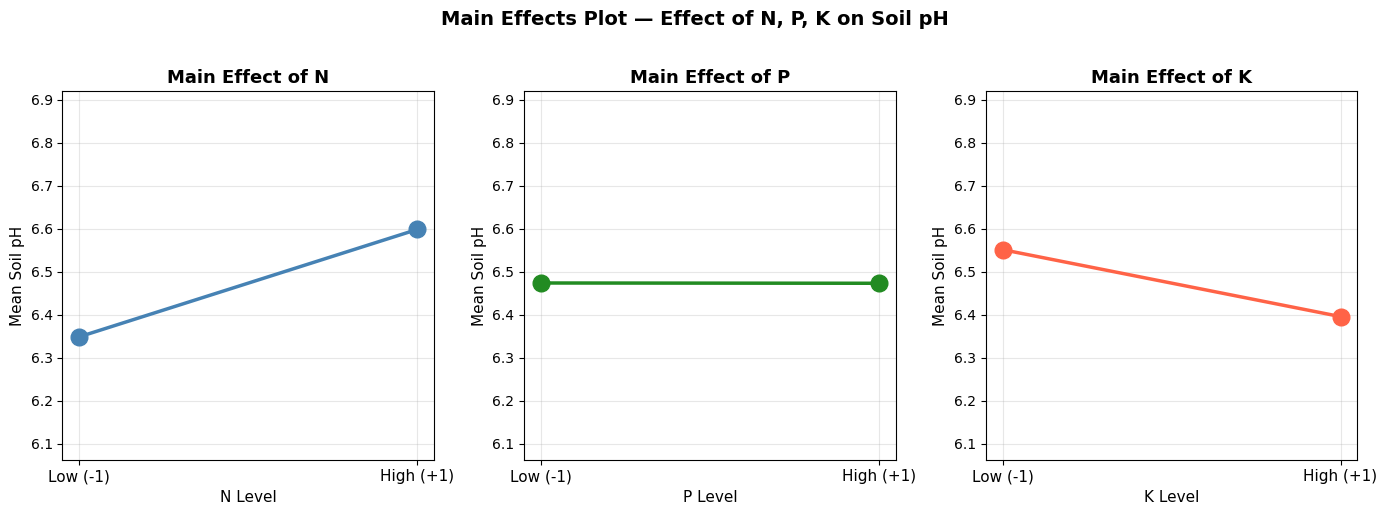

✅ Main effects plot saved!


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
factors = ['N', 'P', 'K']
colors = ['steelblue', 'forestgreen', 'tomato']

for i, (factor, color) in enumerate(zip(factors, colors)):
    means = factorial_table.groupby(factor)['PH'].mean()
    axes[i].plot([-1, 1], means.values,
                 marker='o', markersize=12,
                 linewidth=2.5, color=color)
    axes[i].set_xticks([-1, 1])
    axes[i].set_xticklabels(['Low (-1)', 'High (+1)'], fontsize=11)
    axes[i].set_title(f'Main Effect of {factor}',
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Mean Soil pH', fontsize=11)
    axes[i].set_xlabel(f'{factor} Level', fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(factorial_table['PH'].min() - 0.2,
                     factorial_table['PH'].max() + 0.2)

plt.suptitle('Main Effects Plot — Effect of N, P, K on Soil pH',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('main_effects_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Main effects plot saved!")

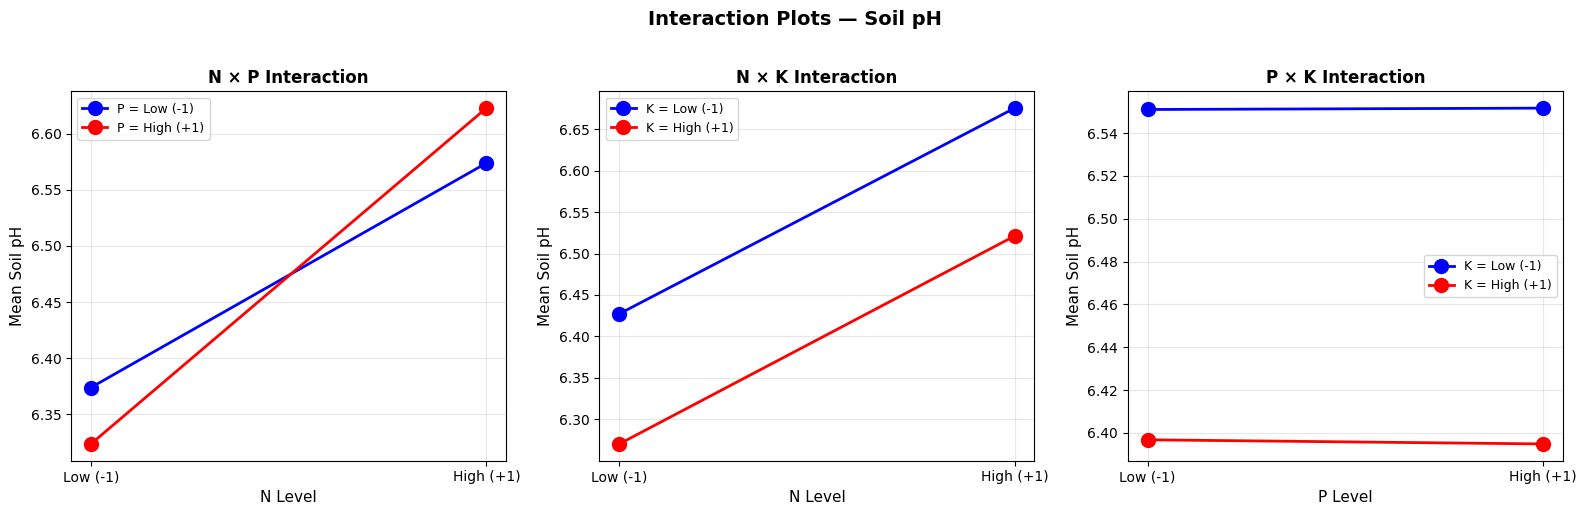

✅ Interaction plots saved!


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
interactions = [('N','P'), ('N','K'), ('P','K')]
titles = ['N × P Interaction',
          'N × K Interaction',
          'P × K Interaction']

for i, ((f1, f2), title) in enumerate(zip(interactions, titles)):
    for level, color, label in [(-1,'blue','Low (-1)'),
                                  (1,'red','High (+1)')]:
        subset = factorial_table[factorial_table[f2] == level]
        means = subset.groupby(f1)['PH'].mean()
        axes[i].plot([-1, 1], means.values,
                    marker='o', markersize=10,
                    linewidth=2, color=color,
                    label=f'{f2} = {label}')

    axes[i].set_xticks([-1, 1])
    axes[i].set_xticklabels(['Low (-1)', 'High (+1)'])
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{f1} Level', fontsize=11)
    axes[i].set_ylabel('Mean Soil pH', fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Interaction Plots — Soil pH',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('interaction_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Interaction plots saved!")

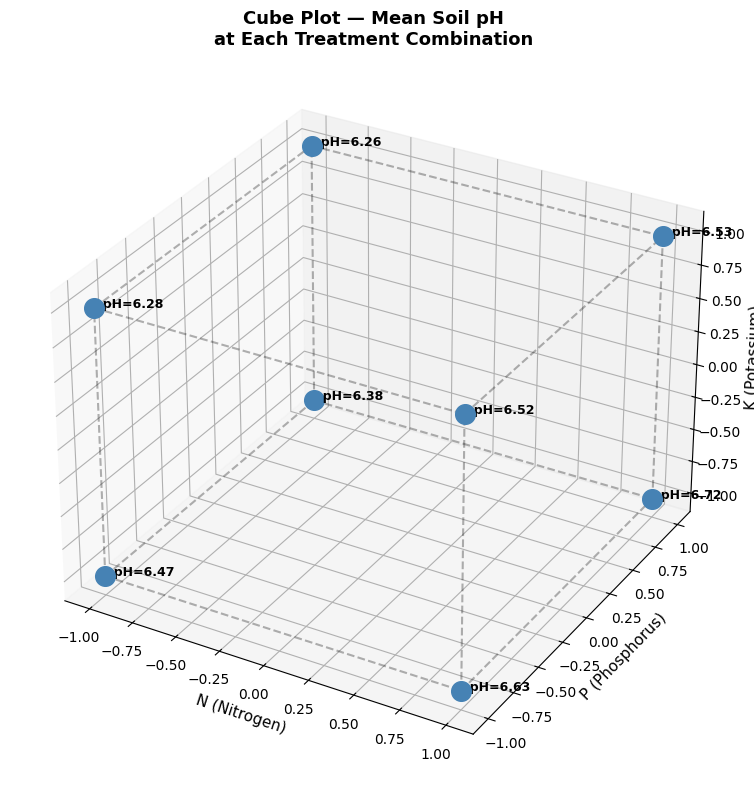

✅ Cube plot saved!


In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot cube corners
for _, row in factorial_table.iterrows():
    ax.scatter(row['N'], row['P'], row['K'],
               s=200, c='steelblue', zorder=5)
    ax.text(row['N'], row['P'], row['K'],
            f"  pH={row['PH']:.2f}",
            fontsize=9, fontweight='bold')

# Draw cube edges
for x in [-1, 1]:
    for y in [-1, 1]:
        ax.plot([x,x],[y,y],[-1,1], 'k--', alpha=0.3)
for x in [-1, 1]:
    for z in [-1, 1]:
        ax.plot([x,x],[-1,1],[z,z], 'k--', alpha=0.3)
for y in [-1, 1]:
    for z in [-1, 1]:
        ax.plot([-1,1],[y,y],[z,z], 'k--', alpha=0.3)

ax.set_xlabel('N (Nitrogen)', fontsize=11)
ax.set_ylabel('P (Phosphorus)', fontsize=11)
ax.set_zlabel('K (Potassium)', fontsize=11)
ax.set_title('Cube Plot — Mean Soil pH\nat Each Treatment Combination',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('cube_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cube plot saved!")

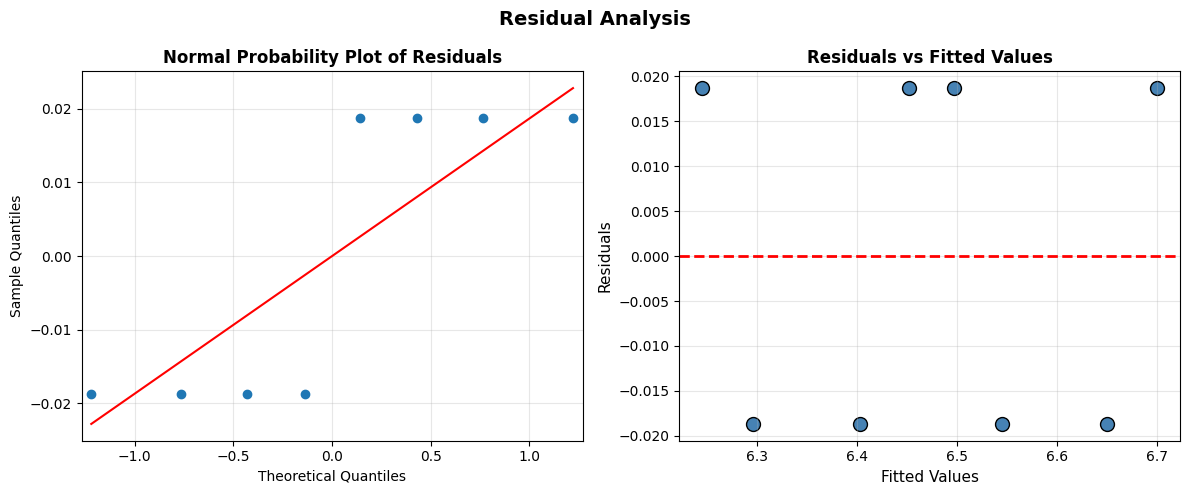

✅ Residual plots saved!


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal probability plot
residuals = model.resid
sm.qqplot(residuals, line='s', ax=axes[0])
axes[0].set_title('Normal Probability Plot of Residuals',
                   fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals vs Fitted
fitted = model.fittedvalues
axes[1].scatter(fitted, residuals,
                color='steelblue', s=100, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residuals vs Fitted Values',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Residual plots saved!")

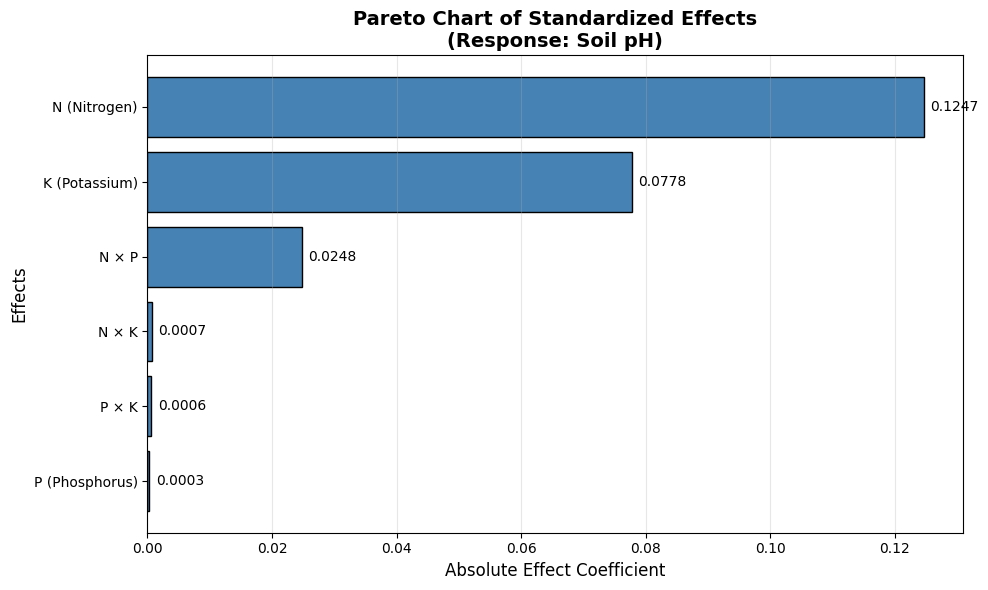

✅ Pareto plot saved!


In [30]:

import matplotlib.pyplot as plt
import numpy as np

# Get coefficients excluding intercept
coefficients = model.params.drop('Intercept')

# Calculate absolute effects
abs_effects = coefficients.abs().sort_values(ascending=True)

# Rename for cleaner labels
label_map = {
    'N': 'N (Nitrogen)',
    'P': 'P (Phosphorus)',
    'K': 'K (Potassium)',
    'N:P': 'N × P',
    'N:K': 'N × K',
    'P:K': 'P × K'
}
abs_effects.index = [label_map.get(i, i) for i in abs_effects.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(abs_effects.index,
               abs_effects.values,
               color='steelblue',
               edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, abs_effects.values):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}',
            va='center', fontsize=10)

ax.set_title('Pareto Chart of Standardized Effects\n(Response: Soil pH)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Effect Coefficient', fontsize=12)
ax.set_ylabel('Effects', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('pareto_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pareto plot saved!")

In [31]:
from google.colab import files
import os

# List of files to download
file_list = [
    'factorial_doe_table.csv',
    'pareto_plot.png',
    'main_effects_plot.png',
    'interaction_plots.png',
    'cube_plot.png',
    'residual_plots.png'
]

# Save factorial table first
factorial_table.to_csv('factorial_doe_table.csv', index=False)

# Download only if file exists
for f in file_list:
    if os.path.exists(f):
        files.download(f)
        print(f"✅ Downloaded: {f}")
    else:
        print(f"❌ Not found: {f} — check if that cell ran successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: factorial_doe_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: cube_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: residual_plots.png


In [33]:
from google.colab import files
import os

# List of files to download
file_list = [
    'factorial_doe_table.csv',
    'pareto_plot.png',
    'main_effects_plot.png',
    'interaction_plots.png',
    'cube_plot.png',
    'residual_plots.png'
]

# Save factorial table first
factorial_table.to_csv('factorial_doe_table.csv', index=False)

# Download only if file exists
for f in file_list:
    if os.path.exists(f):
        files.download(f)
        print(f"✅ Downloaded: {f}")
    else:
        print(f"❌ Not found: {f} — check if that cell ran successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: factorial_doe_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: cube_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: residual_plots.png


## Google Colab is available in VS Code!
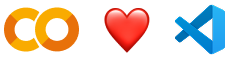

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [15]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  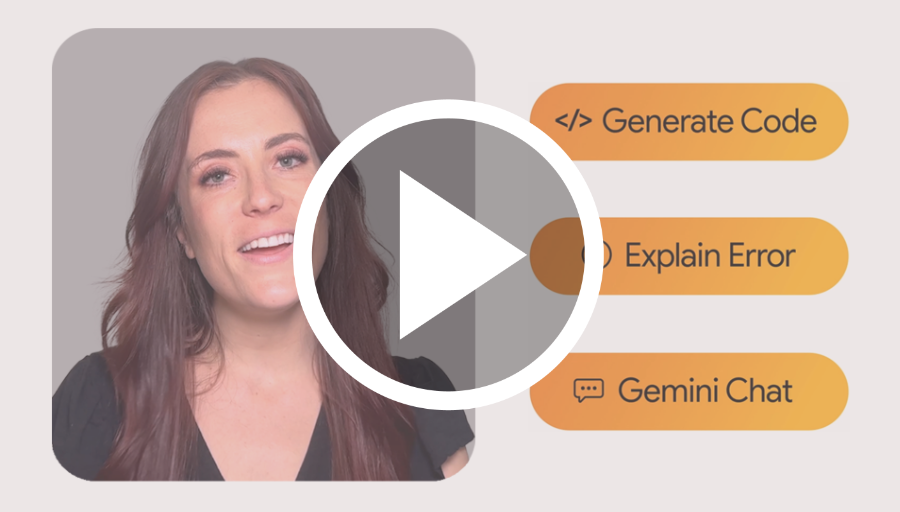
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [16]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [17]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

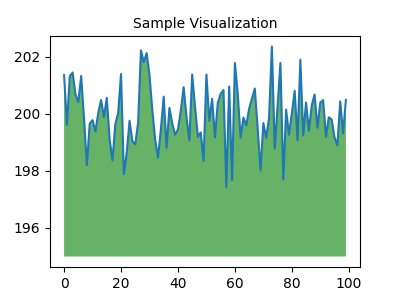

In [18]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
